# CommonLID Language Extension: CLD2 Evaluation

Analysis of experiments extending CLD2's language coverage across the CommonLID benchmark.
Goal: maximize **macro F1** and **micro F1** across all 89 evaluated languages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load experiment results
df = pd.read_csv("results_lid.tsv", sep="\t")
for col in ["macro_f1", "micro_f1", "coverage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Load per-language results (from latest evaluation run)
lang_df = pd.read_csv("data/evaluation/results/per_language.tsv", sep="\t")

# Load confusion matrix
conf_df = pd.read_csv("data/evaluation/results/confusion.tsv", sep="\t")

print(f"Experiments: {len(df)}")
print(f"Languages evaluated: {len(lang_df[lang_df['n_samples'] > 0])}")
df

Experiments: 11
Languages evaluated: 89


,commit,macro_f1,micro_f1,coverage,status,description
0,91040a9,0.4650,0.8694,1.0,keep,baseline (vanilla CLD2)
1,e19a6ad,0.4885,0.8818,1.0,keep,add kQuad_obj2 with 30 languages (32K buckets)
2,be2555e,0.5211,0.8810,1.0,keep,add PLang for 19 new langs + 128K bucket table
3,c980475,0.6015,0.8918,1.0,keep,dual-table scoring (both tables contribute hits)
4,b53bd18,0.6006,0.8905,1.0,keep,remove contrast filtering (simpler + better)
5,692b6bc,0.6921,0.8965,1.0,keep,switch to 0122 tables + focused table 2 (10K/l...
6,c8c0fba,0.7044,0.9175,1.0,keep,contrast filtering for table 2 against 0122 langs
7,d69afa8,0.7117,0.9249,1.0,keep,"5K quad/lang, remove pcm/guw/gom (high FP)"
8,6133642,0.7243,0.9262,1.0,keep,contrast threshold=1.0 (optimal)
9,4390008,0.7258,0.9261,1.0,keep,4K quad/lang + Latvian contrast (optimal)


## Metrics Over Experiments

Track how macro F1, micro F1, and language coverage evolve across experiments.

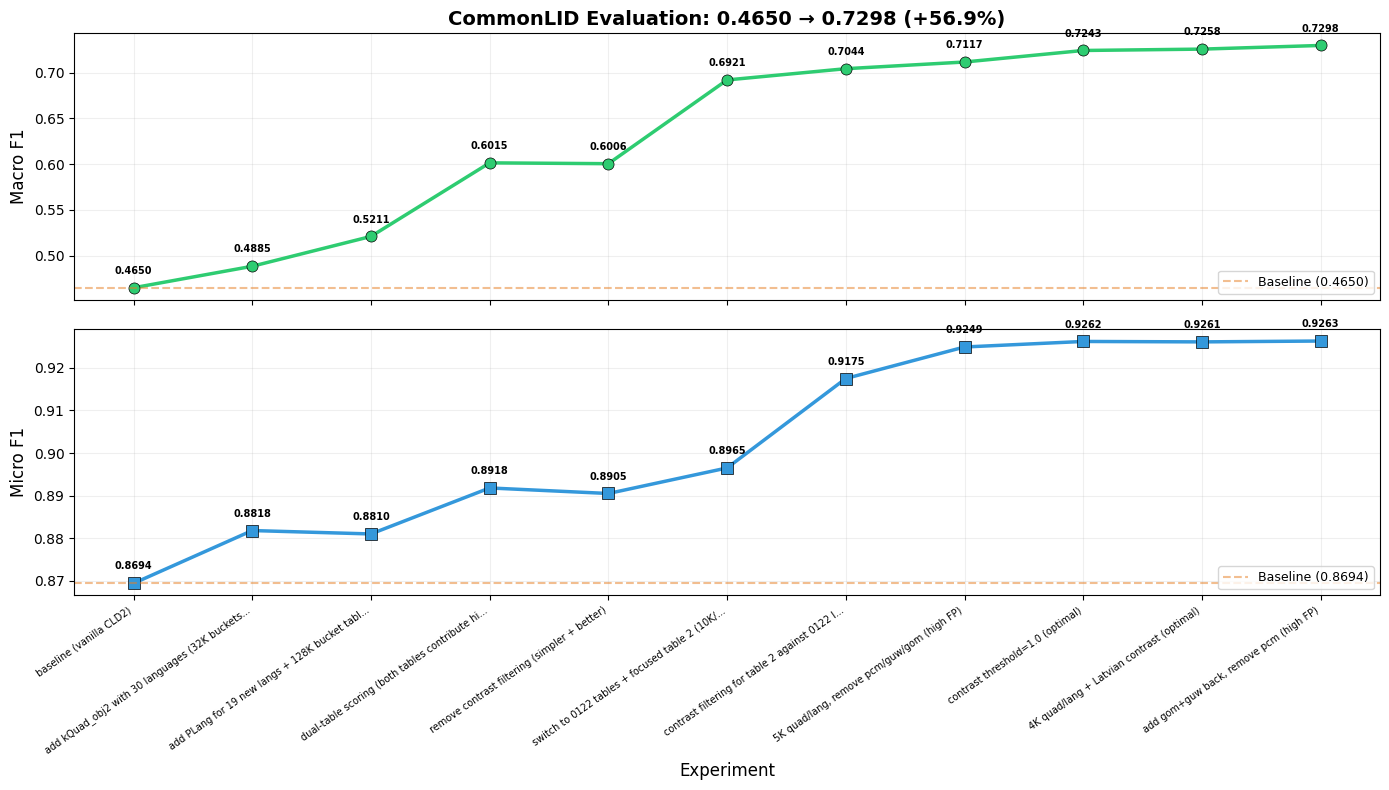

Saved to progress_lid.png


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = range(len(df))
labels = [d[:45] + "..." if len(d) > 45 else d for d in df["description"]]

# Macro F1
ax = axes[0]
ax.plot(x, df["macro_f1"], "o-", color="#2ecc71", linewidth=2.5, markersize=8,
        markeredgecolor="black", markeredgewidth=0.5)
ax.axhline(y=df.iloc[0]["macro_f1"], color="#e67e22", linestyle="--", alpha=0.5,
           label=f"Baseline ({df.iloc[0]['macro_f1']:.4f})")
for i, (xi, v) in enumerate(zip(x, df["macro_f1"])):
    ax.annotate(f"{v:.4f}", (xi, v), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=7, fontweight="bold")
ax.set_ylabel("Macro F1", fontsize=12)
delta = df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']
pct = delta / df.iloc[0]['macro_f1'] * 100
ax.set_title(f"CommonLID Evaluation: {df.iloc[0]['macro_f1']:.4f} \u2192 {df.iloc[-1]['macro_f1']:.4f} "
             f"(+{pct:.1f}%)",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Micro F1
ax = axes[1]
ax.plot(x, df["micro_f1"], "s-", color="#3498db", linewidth=2.5, markersize=8,
        markeredgecolor="black", markeredgewidth=0.5)
ax.axhline(y=df.iloc[0]["micro_f1"], color="#e67e22", linestyle="--", alpha=0.5,
           label=f"Baseline ({df.iloc[0]['micro_f1']:.4f})")
for i, (xi, v) in enumerate(zip(x, df["micro_f1"])):
    ax.annotate(f"{v:.4f}", (xi, v), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=7, fontweight="bold")
ax.set_ylabel("Micro F1", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7)
ax.set_xlabel("Experiment", fontsize=12)

plt.tight_layout()
plt.savefig("progress_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress_lid.png")

## Per-Language F1 Scores

F1 score for each of the 90 CommonLID languages (after normalization), sorted by sample count.
Languages with F1=0 are either unsupported or have too few samples for reliable detection.

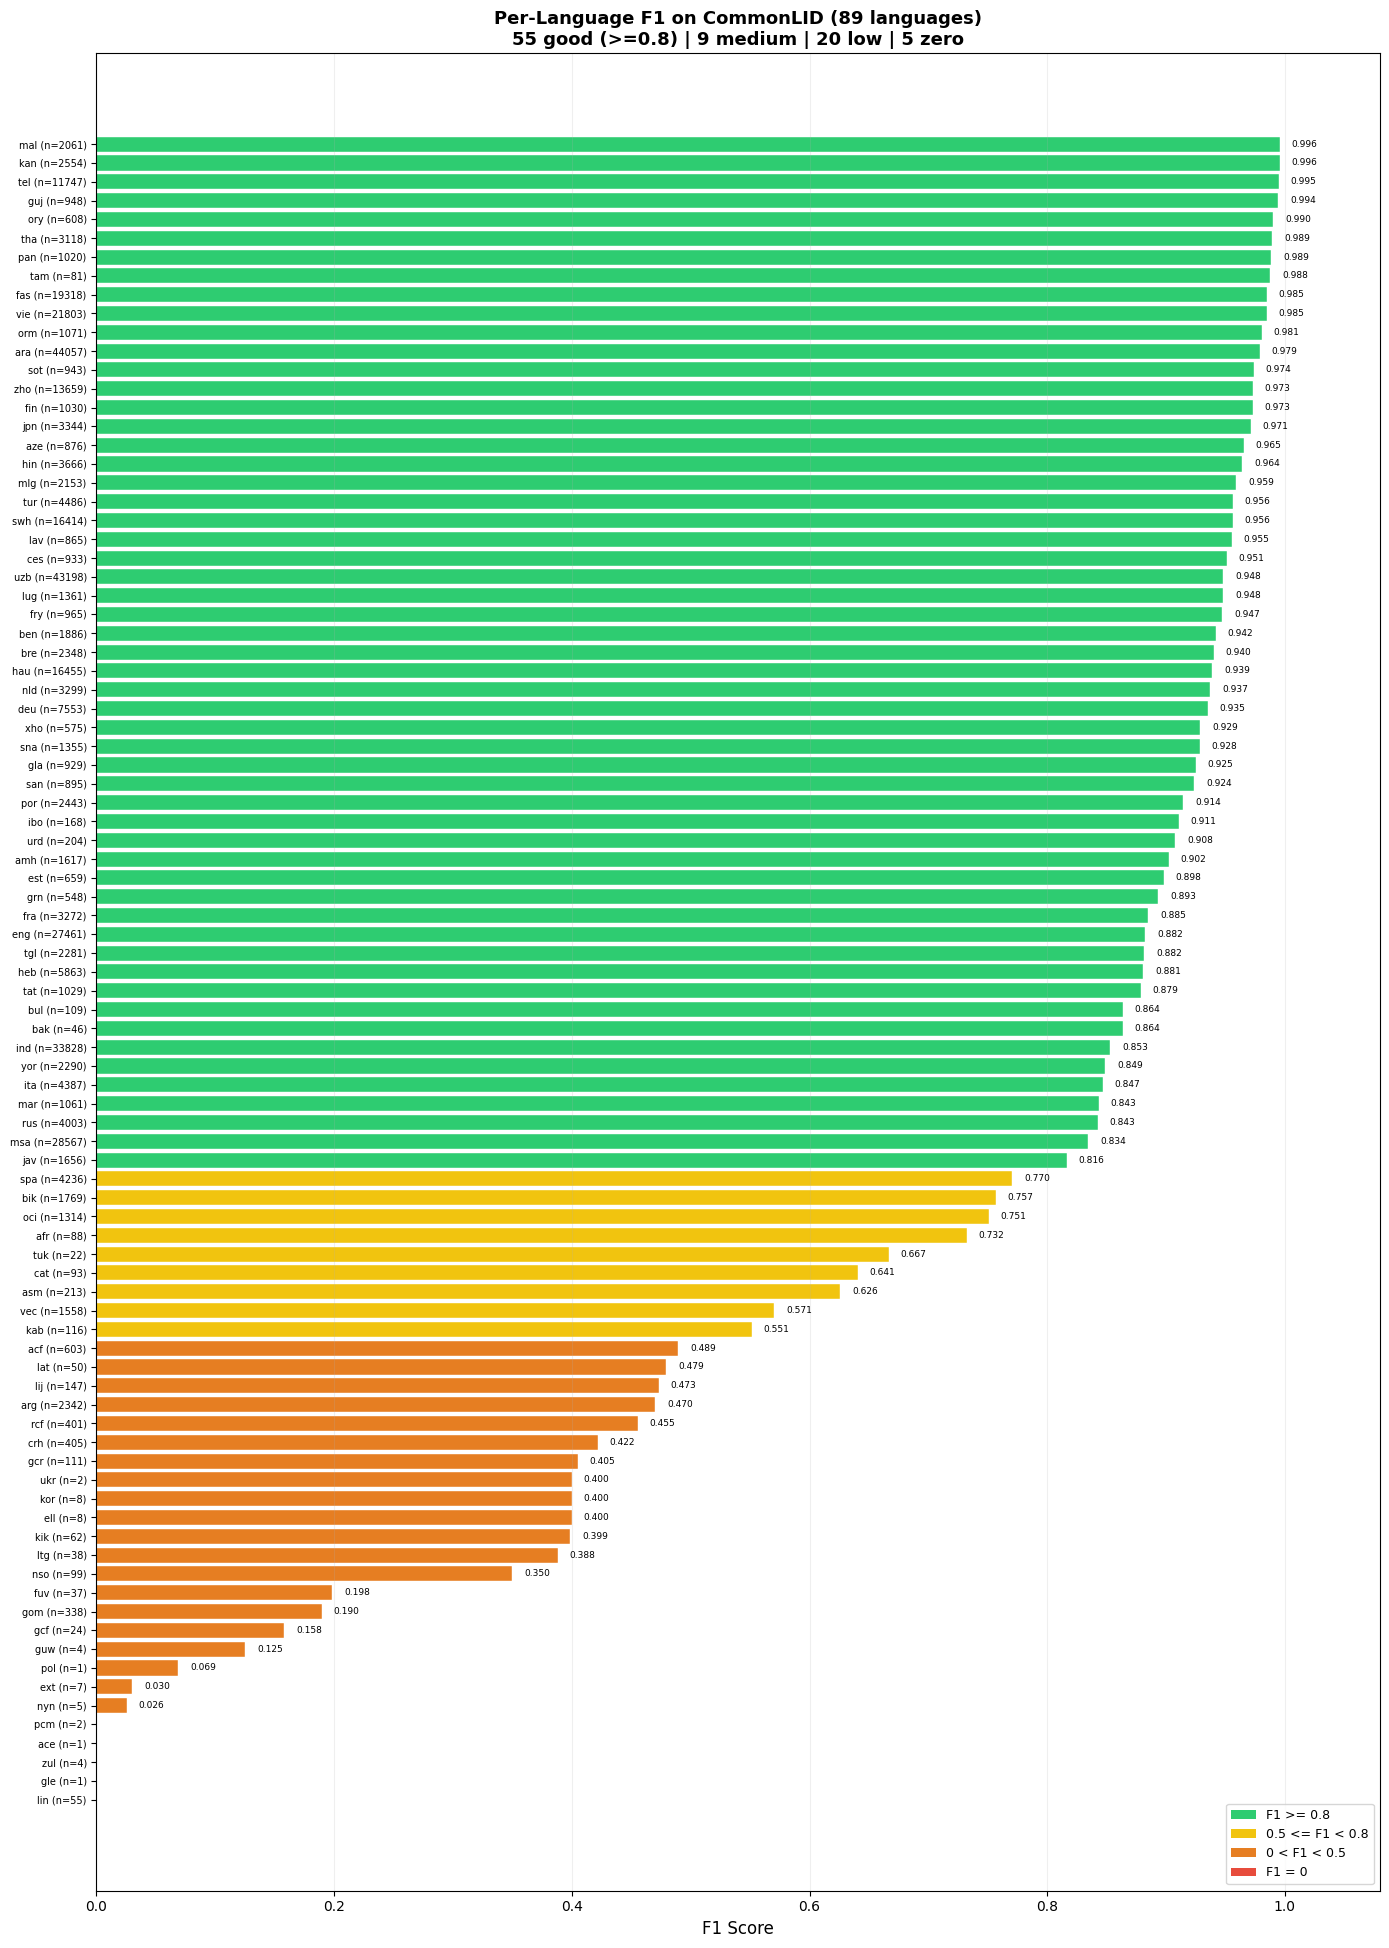

Saved to perlang_f1.png


In [3]:
# Filter to languages with >0 samples in ground truth
gt = lang_df[lang_df["n_samples"] > 0].copy()
gt = gt.sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(12, len(gt) * 0.22)))

colors = []
for _, row in gt.iterrows():
    if row["f1"] == 0:
        colors.append("#e74c3c")
    elif row["f1"] < 0.5:
        colors.append("#e67e22")
    elif row["f1"] < 0.8:
        colors.append("#f1c40f")
    else:
        colors.append("#2ecc71")

bars = ax.barh(range(len(gt)), gt["f1"], color=colors, edgecolor="white", linewidth=0.3)

# Labels: lang code + sample count
ylabels = [f"{row['lang']} (n={row['n_samples']})" for _, row in gt.iterrows()]
ax.set_yticks(range(len(gt)))
ax.set_yticklabels(ylabels, fontsize=7)

# Value labels
for i, (_, row) in enumerate(gt.iterrows()):
    if row["f1"] > 0:
        ax.text(row["f1"] + 0.01, i, f"{row['f1']:.3f}", va="center", fontsize=6.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="F1 >= 0.8"),
    Patch(facecolor="#f1c40f", label="0.5 <= F1 < 0.8"),
    Patch(facecolor="#e67e22", label="0 < F1 < 0.5"),
    Patch(facecolor="#e74c3c", label="F1 = 0"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

n_good = len(gt[gt["f1"] >= 0.8])
n_mid = len(gt[(gt["f1"] >= 0.5) & (gt["f1"] < 0.8)])
n_low = len(gt[(gt["f1"] > 0) & (gt["f1"] < 0.5)])
n_zero = len(gt[gt["f1"] == 0])

ax.set_xlabel("F1 Score", fontsize=12)
ax.set_title(f"Per-Language F1 on CommonLID ({len(gt)} languages)\n"
             f"{n_good} good (>=0.8) | {n_mid} medium | {n_low} low | {n_zero} zero",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.08)
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("perlang_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to perlang_f1.png")

## Top Confusion Pairs

The most common misclassifications. `und` = CLD2 returned "Unknown" (short/ambiguous text).

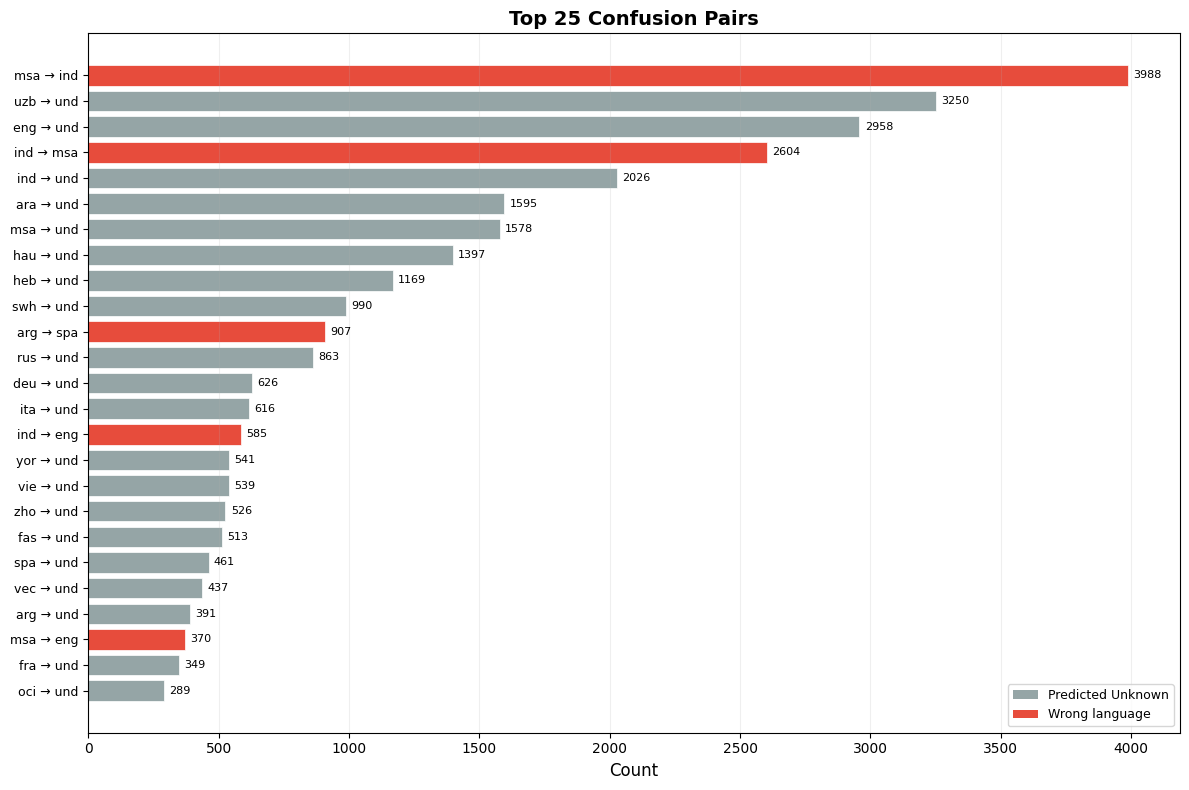

Saved to confusion_lid.png


In [4]:
top_conf = conf_df.head(25).copy()
top_conf["label"] = top_conf["true_lang"] + " \u2192 " + top_conf["pred_lang"]
top_conf = top_conf.iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(12, 8))

colors = ["#95a5a6" if row["pred_lang"] == "und" else "#e74c3c"
          for _, row in top_conf.iterrows()]

ax.barh(range(len(top_conf)), top_conf["count"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top_conf)))
ax.set_yticklabels(top_conf["label"], fontsize=9)

for i, val in enumerate(top_conf["count"]):
    ax.text(val + 20, i, str(val), va="center", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#95a5a6", label="Predicted Unknown"),
    Patch(facecolor="#e74c3c", label="Wrong language"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_xlabel("Count", fontsize=12)
ax.set_title("Top 25 Confusion Pairs", fontsize=14, fontweight="bold")
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("confusion_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to confusion_lid.png")

## Summary Statistics

In [5]:
gt = lang_df[lang_df["n_samples"] > 0].copy()
total_samples = gt["n_samples"].sum()

print("=" * 60)
print("CommonLID Evaluation Summary")
print("=" * 60)
print(f"Total samples:        {total_samples:,}")
print(f"Total languages:      {len(gt)}")
print(f"Supported languages:  {len(gt[gt['supported'] == 'yes'])}")
print()
print(f"Macro F1:  {df.iloc[0]['macro_f1']:.4f} -> {df.iloc[-1]['macro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']):.4f})")
print(f"Micro F1:  {df.iloc[0]['micro_f1']:.4f} -> {df.iloc[-1]['micro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['micro_f1'] - df.iloc[0]['micro_f1']):.4f})")
print()

# Top/bottom languages by F1
gt_with_f1 = gt[gt["n_samples"] >= 10].sort_values("f1", ascending=False)
print("Top 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.head(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

print(f"\nBottom 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.tail(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

# Biggest error sources
print(f"\nTop 10 confusion pairs:")
for _, row in conf_df.head(10).iterrows():
    print(f"  {row['true_lang']:>5} -> {row['pred_lang']:<5}  {row['count']:>5}")

CommonLID Evaluation Summary
Total samples:        373,230
Total languages:      89
Supported languages:  89

Macro F1:  0.4650 -> 0.7298  (+0.2648)
Micro F1:  0.8694 -> 0.9263  (+0.0569)

Top 10 languages (by F1, n>=10):
  mal      F1=0.9956  P=1.000  R=0.991  n=2061
  kan      F1=0.9955  P=1.000  R=0.991  n=2554
  tel      F1=0.9948  P=1.000  R=0.990  n=11747
  guj      F1=0.9942  P=1.000  R=0.988  n=948
  ory      F1=0.9900  P=1.000  R=0.980  n=608
  tha      F1=0.9892  P=0.996  R=0.983  n=3118
  pan      F1=0.9887  P=0.994  R=0.983  n=1020
  tam      F1=0.9878  P=0.976  R=1.000  n=81
  fas      F1=0.9846  P=0.999  R=0.970  n=19318
  vie      F1=0.9845  P=1.000  R=0.970  n=21803

Bottom 10 languages (by F1, n>=10):
  rcf      F1=0.4553  P=0.498  R=0.419  n=401
  crh      F1=0.4218  P=0.524  R=0.353  n=405
  gcr      F1=0.4050  P=0.374  R=0.441  n=111
  kik      F1=0.3985  P=0.258  R=0.871  n=62
  ltg      F1=0.3881  P=0.448  R=0.342  n=38
  nso      F1=0.3500  P=1.000  R=0.212  n=99

## New Languages Added

Performance of the 20 new languages added to CLD2 via quadgram table generation.

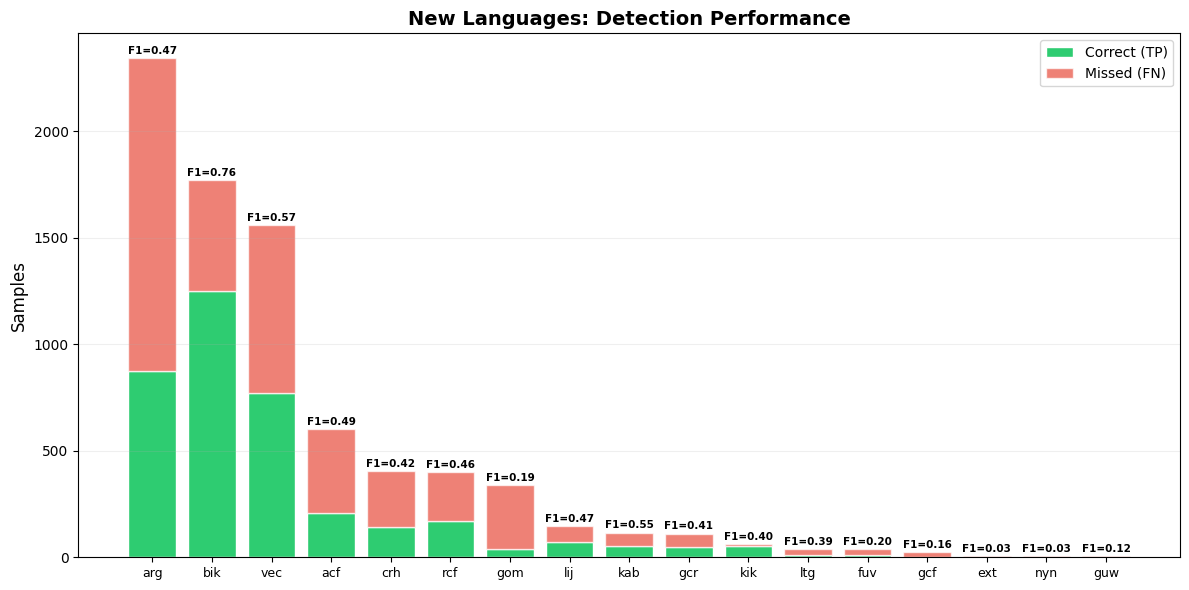

Saved to new_langs.png

Lang    Samples     TP     FP     FN      P      R     F1
-------------------------------------------------------
arg        2342    874    502   1468  0.635  0.373  0.470
bik        1769   1248    281    521  0.816  0.706  0.757
vec        1558    773    379    785  0.671  0.496  0.571
acf         603    210     45    393  0.824  0.348  0.489
crh         405    143    130    262  0.524  0.353  0.422
rcf         401    168    169    233  0.498  0.419  0.455
gom         338     37     15    301  0.712  0.110  0.190
lij         147     71     82     76  0.464  0.483  0.473
kab         116     51     18     65  0.739  0.440  0.551
gcr         111     49     82     62  0.374  0.441  0.405
kik          62     54    155      8  0.258  0.871  0.399
ltg          38     13     16     25  0.448  0.342  0.388
fuv          37     12     72     25  0.143  0.324  0.198
gcf          24      3     11     21  0.214  0.125  0.158
ext           7      2    124      5  0.016  0.286

In [6]:
new_langs = ["arg", "vec", "bik", "acf", "crh", "rcf", "gom",
             "lij", "kab", "gcr", "kik", "ltg", "fuv", "gcf",
             "ext", "nyn", "guw"]

new_df = lang_df[lang_df["lang"].isin(new_langs) & (lang_df["n_samples"] > 0)].copy()
new_df = new_df.sort_values("n_samples", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(new_df))

# Stacked: TP (green), FN (red)
ax.bar(x, new_df["tp"], color="#2ecc71", label="Correct (TP)", edgecolor="white")
ax.bar(x, new_df["fn"], bottom=new_df["tp"], color="#e74c3c",
       label="Missed (FN)", edgecolor="white", alpha=0.7)

# F1 annotations
for i, (_, row) in enumerate(new_df.iterrows()):
    total = row["tp"] + row["fn"]
    ax.text(i, total + 20, f"F1={row['f1']:.2f}", ha="center", fontsize=7.5, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(new_df["lang"], fontsize=9)
ax.set_ylabel("Samples", fontsize=12)
ax.set_title("New Languages: Detection Performance", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("new_langs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to new_langs.png")

# Table
print(f"\n{'Lang':<6} {'Samples':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'P':>6} {'R':>6} {'F1':>6}")
print("-" * 55)
for _, row in new_df.iterrows():
    print(f"{row['lang']:<6} {row['n_samples']:>8} {row['tp']:>6} {row['fp']:>6} {row['fn']:>6} "
          f"{row['precision']:>6.3f} {row['recall']:>6.3f} {row['f1']:>6.3f}")